# Generator analysis from grid data

Compare the empirical population map, its second-order generator approximation, and the full-channel spectral separation.


In [2]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PLOT_DIR = Path('docu/plots')
PLOT_DIR.mkdir(parents=True, exist_ok=True)


## Load grid


In [3]:
grid_nr = 6
N = 4
path = Path(f'data/grid/superoperator_N{N}_grid_{grid_nr}.npz')

data = np.load(path)
grid_h_over_J = data['h_over_J'] if 'h_over_J' in data.files else data['h']

print(f'Loaded: {path}')
print(f"Grid points: {len(data['h'])}")
print('alpha values:', np.unique(data['alpha']).tolist())
print('sigma values:', np.unique(data['sigma']).tolist())


Loaded: data/grid/superoperator_N4_grid_6.npz
Grid points: 200
alpha values: [0.02, 0.04000000000000001, 0.06000000000000001, 0.08000000000000002, 0.10000000000000002, 0.12000000000000002, 0.14, 0.16, 0.18000000000000002, 0.2, 0.22, 0.24, 0.26, 0.28, 0.30000000000000004, 0.32, 0.34, 0.36, 0.38, 0.4]
sigma values: [1.0]


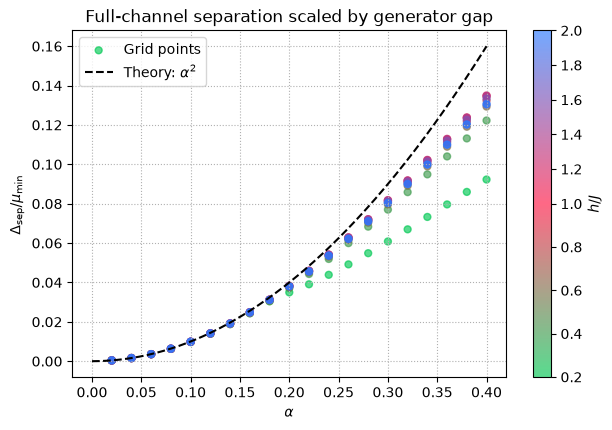

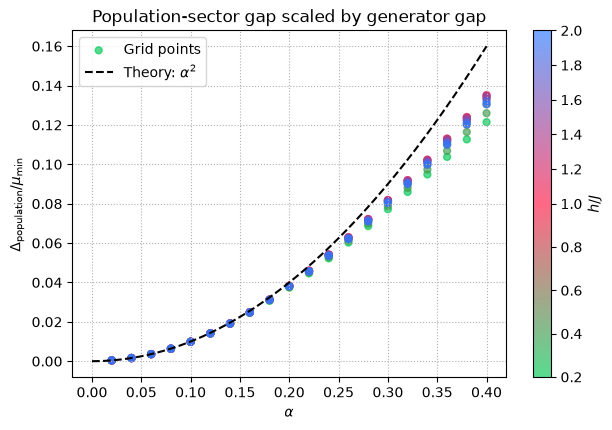

,h_over_J,alpha,generator_gap,Delta_sep,ratio
0,0.2,0.02,0.470355,0.000187,0.000398
1,0.2,0.04,0.470355,0.000746,0.001587
2,0.2,0.06,0.470355,0.001674,0.003559
3,0.2,0.08,0.470355,0.002962,0.006298
4,0.2,0.10,0.470355,0.004601,0.009782
...,...,...,...,...,...
195,2.0,0.32,0.363086,0.032666,0.089968
196,2.0,0.34,0.363086,0.036266,0.099883
197,2.0,0.36,0.363086,0.039944,0.110012
198,2.0,0.38,0.363086,0.043678,0.120296


In [19]:
import matplotlib.colors as mcolors

# The theory predicts Delta_sep / mu_min approximately equals alpha^2,
# where mu_min is the smallest positive generator decay rate.
required_keys = {'transition_generator', 'classical_populations', 'Delta_sep', 'alpha'}
missing_keys = required_keys.difference(data.files)
if missing_keys:
    raise KeyError(f'Missing required grid data: {sorted(missing_keys)}')

def generator_gap(generator):
    eigvals = np.linalg.eigvals(generator)
    stationary_index = np.argmin(np.abs(eigvals))
    nonstationary_eigvals = np.delete(eigvals, stationary_index)
    return -np.max(np.real(nonstationary_eigvals))

def population_gap(population_map):
    eigvals = np.linalg.eigvals(population_map)
    stationary_index = np.argmin(np.abs(eigvals - 1))
    nonstationary_eigvals = np.delete(eigvals, stationary_index)
    return 1 - np.max(np.abs(nonstationary_eigvals))

scaling_rows = []
for row_index, generator in enumerate(data['transition_generator']):
    alpha = float(data['alpha'][row_index])
    mu_min = generator_gap(generator)
    delta_sep = float(data['Delta_sep'][row_index])
    if np.isfinite(mu_min) and mu_min > 0 and np.isfinite(delta_sep):
        scaling_rows.append({
            'h_over_J': float(grid_h_over_J[row_index]),
            'alpha': alpha,
            'generator_gap': mu_min,
            'Delta_sep': delta_sep,
            'ratio': delta_sep / mu_min,
        })

scaling_data = pd.DataFrame(scaling_rows)
if scaling_data.empty:
    raise ValueError('No grid rows have a positive finite generator gap.')

fig, ax = plt.subplots(figsize=(7, 4.5))
h_norm = mcolors.TwoSlopeNorm(
    vmin=scaling_data['h_over_J'].min(), vcenter=1.0, vmax=scaling_data['h_over_J'].max()
)
h_cmap = mcolors.LinearSegmentedColormap.from_list(
    'h_over_J', ['#00c853', '#ff1744', '#2979ff']
)
points = ax.scatter(
    scaling_data['alpha'], scaling_data['ratio'], c=scaling_data['h_over_J'],
    cmap=h_cmap, norm=h_norm, s=25, alpha=0.65, label='Grid points'
)
colorbar = fig.colorbar(points, ax=ax)
colorbar.set_label(r'$h/J$')
alpha_theory = np.linspace(0, scaling_data['alpha'].max(), 200)
ax.plot(alpha_theory, alpha_theory**2, color='black', linestyle='--', label=r'Theory: $\alpha^2$')
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'$\Delta_{\mathrm{sep}} / \mu_{\min}$')
ax.set_title(r'Full-channel separation scaled by generator gap')
ax.grid(True, linestyle=':')
ax.legend()
plt.show()

population_scaling_rows = []
for row_index, (population_map, generator) in enumerate(
    zip(data['classical_populations'], data['transition_generator'])
):
    alpha = float(data['alpha'][row_index])
    mu_min = generator_gap(generator)
    delta_population = population_gap(population_map)
    if np.isfinite(mu_min) and mu_min > 0 and np.isfinite(delta_population):
        population_scaling_rows.append({
            'h_over_J': float(grid_h_over_J[row_index]),
            'alpha': alpha,
            'generator_gap': mu_min,
            'population_gap': delta_population,
            'ratio': delta_population / mu_min,
        })

population_scaling_data = pd.DataFrame(population_scaling_rows)
if population_scaling_data.empty:
    raise ValueError('No grid rows have a positive finite population-sector generator gap.')

fig, ax = plt.subplots(figsize=(7, 4.5))
population_points = ax.scatter(
    population_scaling_data['alpha'], population_scaling_data['ratio'],
    c=population_scaling_data['h_over_J'], cmap=h_cmap, norm=h_norm,
    s=25, alpha=0.65, label='Grid points'
)
colorbar = fig.colorbar(population_points, ax=ax)
colorbar.set_label(r'$h/J$')
ax.plot(alpha_theory, alpha_theory**2, color='black', linestyle='--', label=r'Theory: $\alpha^2$')
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'$\Delta_{\mathrm{population}} / \mu_{\min}$')
ax.set_title(r'Population-sector gap scaled by generator gap')
ax.grid(True, linestyle=':')
ax.legend()
plt.show()

scaling_data


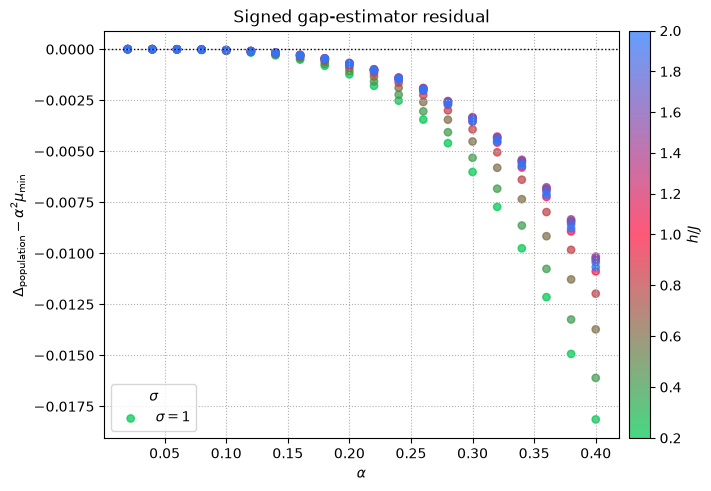

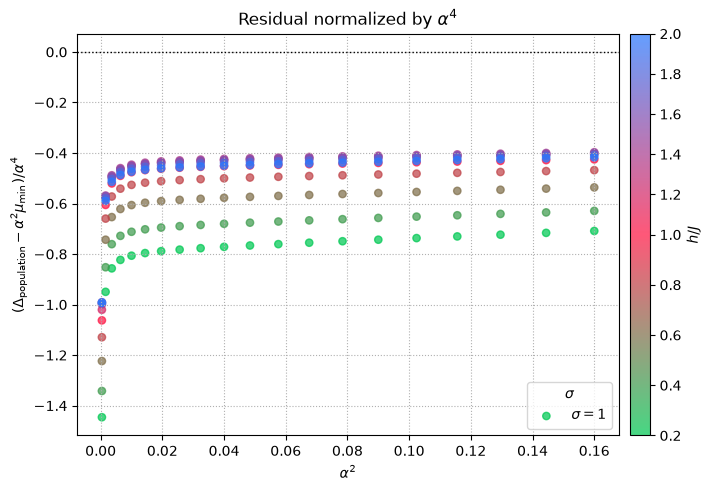

,h_over_J,alpha,sigma,observed_gap,estimated_gap,residual,residual_over_alpha4
0,0.2,0.02,1.0,0.000188,0.000188,-2.313461e-07,-1.445913
1,0.2,0.04,1.0,0.000750,0.000753,-2.430851e-06,-0.949551
2,0.2,0.06,1.0,0.001682,0.001693,-1.110315e-05,-0.856724
3,0.2,0.08,1.0,0.002977,0.003010,-3.371681e-05,-0.823164
4,0.2,0.10,1.0,0.004623,0.004704,-8.064593e-05,-0.806459
...,...,...,...,...,...,...,...
195,2.0,0.32,1.0,0.032655,0.037180,-4.525132e-03,-0.431550
196,2.0,0.34,1.0,0.036251,0.041973,-5.721451e-03,-0.428145
197,2.0,0.36,1.0,0.039924,0.047056,-7.131908e-03,-0.424615
198,2.0,0.38,1.0,0.043652,0.052430,-8.777578e-03,-0.420959


In [21]:
# All-grid comparison of the population-sector gap with the alpha^2 estimator.
import matplotlib.colors as mcolors

residual_rows = []
for row_index, (population_map, generator) in enumerate(
    zip(data['classical_populations'], data['transition_generator'])
):
    alpha = float(data['alpha'][row_index])
    mu_min = generator_gap(generator)
    observed_gap = population_gap(population_map)
    estimated_gap = alpha**2 * mu_min
    if np.isfinite(observed_gap) and np.isfinite(estimated_gap):
        residual_rows.append({
            'h_over_J': float(grid_h_over_J[row_index]),
            'alpha': alpha,
            'sigma': float(data['sigma'][row_index]),
            'observed_gap': observed_gap,
            'estimated_gap': estimated_gap,
            'residual': observed_gap - estimated_gap,
            'residual_over_alpha4': (observed_gap - estimated_gap) / alpha**4,
        })

residual_data = pd.DataFrame(residual_rows)
if residual_data.empty:
    raise ValueError('No finite population-sector gaps are available.')

h_norm = mcolors.TwoSlopeNorm(
    vmin=residual_data['h_over_J'].min(), vcenter=1.0, vmax=residual_data['h_over_J'].max()
)
h_cmap = mcolors.LinearSegmentedColormap.from_list(
    'h_over_J', ['#00c853', '#ff1744', '#2979ff']
)
sigma_markers = dict(zip(np.sort(residual_data['sigma'].unique()), ['o', 's', '^', 'D', 'P']))

fig, residual_ax = plt.subplots(figsize=(7, 4.8), constrained_layout=True)
for sigma, marker in sigma_markers.items():
    sigma_data = residual_data[residual_data['sigma'] == sigma]
    points = residual_ax.scatter(
        sigma_data['alpha'], sigma_data['residual'], c=sigma_data['h_over_J'],
        cmap=h_cmap, norm=h_norm, marker=marker, s=28, alpha=0.72, label=rf'$\sigma={sigma:g}$'
    )
residual_ax.axhline(0, color='black', linewidth=1, linestyle=':')
residual_ax.set_xlabel(r'$\alpha$')
residual_ax.set_ylabel(r'$\Delta_{\mathrm{population}} - \alpha^2\mu_{\min}$')
residual_ax.set_title('Signed gap-estimator residual')
residual_ax.grid(True, linestyle=':')
residual_ax.legend(title=r'$\sigma$')

colorbar = fig.colorbar(points, ax=residual_ax, pad=0.02)
colorbar.set_label(r'$h/J$')
plt.show()

fig, normalized_ax = plt.subplots(figsize=(7, 4.8), constrained_layout=True)
for sigma, marker in sigma_markers.items():
    sigma_data = residual_data[residual_data['sigma'] == sigma]
    points = normalized_ax.scatter(
        sigma_data['alpha']**2, sigma_data['residual_over_alpha4'], c=sigma_data['h_over_J'],
        cmap=h_cmap, norm=h_norm, marker=marker, s=28, alpha=0.72, label=rf'$\sigma={sigma:g}$'
    )

normalized_ax.axhline(0, color='black', linewidth=1, linestyle=':')
normalized_ax.set_xlabel(r'$\alpha^2$')
normalized_ax.set_ylabel(r'$(\Delta_{\mathrm{population}} - \alpha^2\mu_{\min}) / \alpha^4$')
normalized_ax.set_title(r'Residual normalized by $\alpha^4$')
normalized_ax.grid(True, linestyle=':')
normalized_ax.legend(title=r'$\sigma$')
colorbar = fig.colorbar(points, ax=normalized_ax, pad=0.02)
colorbar.set_label(r'$h/J$')
plt.show()

residual_data


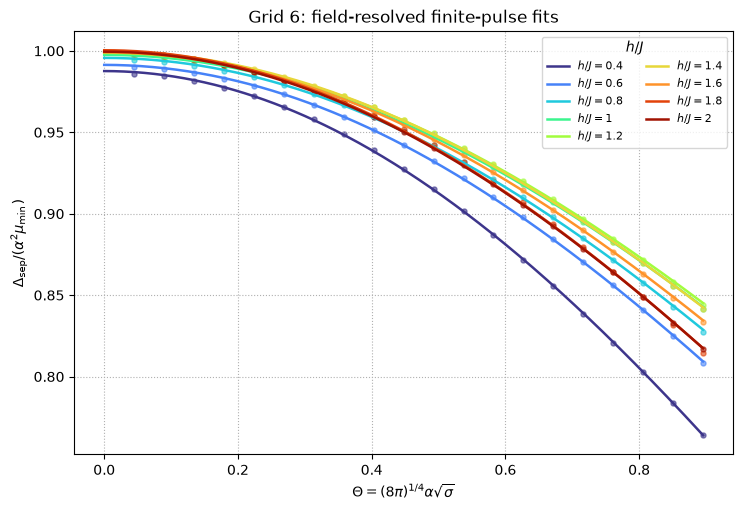

,h_over_J,offset,amplitude,R_squared
0,0.4,0.0573,0.9303,1.0000
1,0.6,0.2337,0.7577,0.9999
2,0.8,0.3013,0.6944,0.9999
3,1.0,0.3539,0.6436,0.9999
4,1.2,0.3597,0.6390,0.9998
5,1.4,0.3458,0.6539,0.9999
6,1.6,0.3144,0.6846,0.9999
7,1.8,0.2390,0.7614,0.9995
8,2.0,0.2417,0.7578,1.0000


In [27]:
# Grid-6 finite-pulse fits: one sinc-squared curve for each fixed h/J.
grid6_path = Path('data/grid/superoperator_N4_grid_6.npz')
grid6_data = np.load(grid6_path)

def grid6_generator_gap(generator):
    eigvals = np.linalg.eigvals(generator)
    stationary_index = np.argmin(np.abs(eigvals))
    return -np.max(np.real(np.delete(eigvals, stationary_index)))

pulse_area_coefficient = (8 * np.pi)**0.25
grid6_rows = []
for row_index, generator in enumerate(grid6_data['transition_generator']):
    alpha = float(grid6_data['alpha'][row_index])
    sigma = float(grid6_data['sigma'][row_index])
    mu_min = grid6_generator_gap(generator)
    delta_sep = float(grid6_data['Delta_sep'][row_index])
    if np.isfinite(mu_min) and mu_min > 0 and np.isfinite(delta_sep):
        theta = pulse_area_coefficient * alpha * np.sqrt(sigma)
        grid6_rows.append({
            'h_over_J': float(grid6_data['h_over_J'][row_index]),
            'theta': theta,
            'ratio': delta_sep / (alpha**2 * mu_min),
        })

grid6_curve_data = pd.DataFrame(grid6_rows)
h_values = np.sort(grid6_curve_data['h_over_J'].unique())
h_values = h_values[~np.isclose(h_values, 0.2)]
h_colors = plt.cm.turbo(np.linspace(0.05, 0.95, len(h_values)))

fig, ax = plt.subplots(figsize=(8.5, 5.5))
fit_summary = []
for h_over_J, color in zip(h_values, h_colors):
    curve_data = grid6_curve_data[grid6_curve_data['h_over_J'] == h_over_J].sort_values('theta')
    sinc_squared = np.sinc(curve_data['theta'] / np.pi)**2
    design_matrix = np.column_stack([np.ones(len(curve_data)), sinc_squared])
    offset, amplitude = np.linalg.lstsq(design_matrix, curve_data['ratio'], rcond=None)[0]
    fitted_ratio = offset + amplitude * sinc_squared
    r_squared = 1 - (
        np.sum((curve_data['ratio'] - fitted_ratio)**2)
        / np.sum((curve_data['ratio'] - curve_data['ratio'].mean())**2)
    )
    theta_line = np.linspace(0, curve_data['theta'].max(), 300)
    ax.scatter(curve_data['theta'], curve_data['ratio'], s=13, color=color, alpha=0.6)
    ax.plot(
        theta_line, offset + amplitude * np.sinc(theta_line / np.pi)**2,
        color=color, linewidth=1.8, label=rf'$h/J={h_over_J:g}$'
    )
    fit_summary.append({
        'h_over_J': h_over_J, 'offset': offset, 'amplitude': amplitude, 'R_squared': r_squared
    })

ax.set_xlabel(r'$\Theta = (8\pi)^{1/4}\alpha\sqrt{\sigma}$')
ax.set_ylabel(r'$\Delta_{\mathrm{sep}} / (\alpha^2\mu_{\min})$')
ax.set_title(r'Grid 6: field-resolved finite-pulse fits')
ax.grid(True, linestyle=':')
ax.legend(title=r'$h/J$', ncol=2, fontsize=8)
plt.show()

pd.DataFrame(fit_summary).round(4)
